In [1]:
"""
Solution for week 14 practice in Data Visualization

Table-based 2D contouring of 2D grid of values
Matplotlib version and custom version
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.collections as mc

In [2]:
# Provided code - build test grid in xy plane
SIZE = 3
x_vals = np.linspace(-SIZE, SIZE,  4 * SIZE + 1)
y_vals = np.linspace(-SIZE, SIZE,  2 * SIZE + 1)
x_grid, y_grid = np.meshgrid(x_vals, y_vals)

In [3]:
# Build three grids of z values
circular = np.vectorize(lambda x, y : (x ** 2 + y ** 2) ** 0.5 - 2.1)
parabolic = np.vectorize(lambda x, y : x - y ** 2 + 0.1)
hyperbolic = np.vectorize(lambda x, y : (x + y + 0.7) ** 2 - (x - y - 0.4) ** 2 + 0.1)

z_circular = circular(x_grid, y_grid)
z_parabolic = parabolic(x_grid, y_grid)
z_hyperbolic = hyperbolic(x_grid, y_grid)

In [4]:
# Part 1 - matplotlib for plotting the zero contour of a gridded function
def plot_contour_plt(x_grid, y_grid, z_grid, title="Contour using plt.contour()"):
    """
    Input: 2D numpy arrays x_grid, y_grid, z_grid, optional string title
    
    Output: matplotlib figure consisting of plot of zero contour of z_grid 
    Display grid induced by x_grid and y_grid using axs.grid()
    """    
    x_vals = x_grid[0, :]
    y_vals = y_grid[:, 0]    
    
    fig, axs = plt.subplots()
    axs.contour(x_grid, y_grid, z_grid, levels=0)
    axs.set_xticks(x_vals)
    axs.set_yticks(y_vals)
    axs.grid()
    axs.set_aspect("equal")
    axs.set_title(title)
    return fig

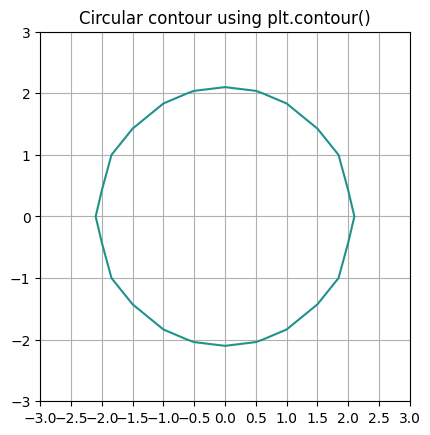

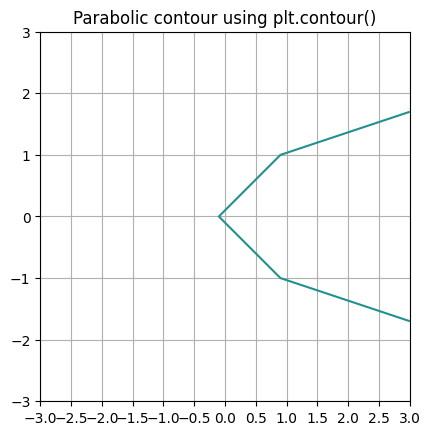

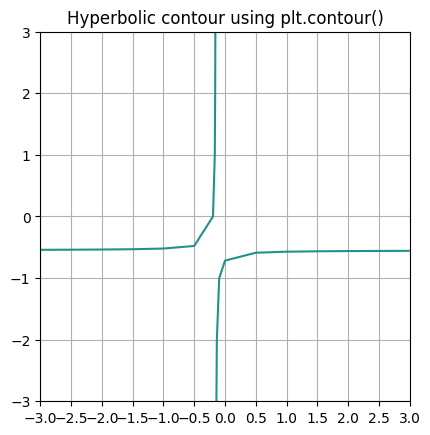

In [5]:
def test_plot_contour_plt():
    """ Test plot_contour_plt on some examples """
    
    plot_contour_plt(x_grid, y_grid, z_circular, "Circular contour using plt.contour()")
    plot_contour_plt(x_grid, y_grid, z_parabolic, "Parabolic contour using plt.contour()")    
    plot_contour_plt(x_grid, y_grid, z_hyperbolic, "Hyperbolic contour using plt.contour()")
    
test_plot_contour_plt()

In [6]:
# Part 2 - custom code for plotting the zero contour of gridded data

VECTOR_SIGN = np.vectorize(lambda x : 1 if x > 0 else -1)

# Dictionary keyed by signs at corner of cell
# Values are sets of line segments for cell
# Each line segment is represent by two cell edges
# Each cell edge is represent by a pair of corner (denoted by 2D index)

SEGMENT_TABLE = {((-1, -1), (-1, -1)) : set([]),
                 ((-1, -1), (-1, 1)) : set([(((0, 1), (1, 1)),((1, 0), (1, 1)))]),
                 ((-1, -1), (1, -1)) : set([(((0, 0), (1, 0)),((1, 0), (1, 1)))]),
                 ((-1, -1), (1, 1)) : set([(((0, 0), (1, 0)),((0, 1), (1, 1)))]),
                 ((-1, 1), (-1, -1)) : set([(((0, 0), (0, 1)),((0, 1), (1, 1)))]),
                 ((-1, 1), (-1, 1)) : set([(((0, 0), (0, 1)),((1, 0), (1, 1)))]),
                 ((-1, 1), (1, -1)) : set([(((0, 0), (0, 1)),((0, 0), (1, 0))), (((0, 1), (1, 1)),((1, 0), (1, 1)))]),
                 ((-1, 1), (1, 1)) : set([(((0, 0), (0, 1)),((0, 0), (1, 0)))]),
                 ((1, -1), (-1, -1)) : set([(((0, 0), (0, 1)),((0, 0), (1, 0)))]),
                 ((1, -1), (-1, 1)) : set([(((0, 0), (0, 1)),((0, 1), (1, 1))), (((0, 0), (1, 0)),((1, 0), (1, 1)))]),
                 ((1, -1), (1, -1)) : set([(((0, 0), (0, 1)),((1, 0), (1, 1)))]),
                 ((1, -1), (1, 1)) : set([(((0, 0), (0, 1)),((0, 1), (1, 1)))]),
                 ((1, 1), (-1, -1)) : set([(((0, 0), (1, 0)),((0, 1), (1, 1)))]),
                 ((1, 1), (-1, 1)) : set([(((0, 0), (1, 0)),((1, 0), (1, 1)))]),
                 ((1, 1), (1, -1)) : set([(((0, 1), (1, 1)),((1, 0), (1, 1)))]),
                 ((1, 1), (1, 1)) : set([])}

In [7]:
def edge_zero(x_edge, y_edge, z_edge):
    """
    Input: 1D numpy arrays x_edge, y_edge, z_edge corrsponding to
    geometry of a cell edge
    
    Output: pair (tuple of floats) where linear function
    interpolating the values in z_edge is zero along the 
    cell edge defined by x_edge and y_edge
    """
    
    alpha0 = -z_edge[1] / (z_edge[0] - z_edge[1])
    alpha1 = z_edge[0] / (z_edge[0] - z_edge[1])
    return (alpha0 * x_edge[0] + alpha1 * x_edge[1],
            alpha0 * y_edge[0] + alpha1 * y_edge[1])

In [8]:
def contour_cell(x_cell, y_cell, z_cell):
    """
    Input: 2x2 numpy arrays x_cell, y_cell, z_cells
    corresponding to (x, y) positions of corners of rectangular cell
    with values z at corners
    
    Output: List of line segments approximating zero contour
    """

    answer = []
    signs = tuple(map(tuple, VECTOR_SIGN(z_cell)))   
    line_segments = SEGMENT_TABLE[signs]
    
    for line_segment in line_segments:
        edge = []
        for (cell_corner0, cell_corner1) in line_segment:
            x_edge = [x_cell[cell_corner0], x_cell[cell_corner1]]
            y_edge = [y_cell[cell_corner0], y_cell[cell_corner1]]
            z_edge = [z_cell[cell_corner0], z_cell[cell_corner1]]
            edge.append(edge_zero(x_edge, y_edge, z_edge))     
        answer.append(edge)
    return answer


##print(contour_cell(np.array([[0, 1], [0, 1]]),
##                   np.array([[0, 0], [1, 1]]),
##                   np.array([[-1, -1], [1, 1]])))

In [9]:
def plot_contour_custom(x_grid, y_grid, z_grid, title="Contour using custom code"):
    """
    Input: 2D numpy arrays x_grid, y_grid, z_grid, optional string title
    
    Output: matplotlib figure consisting of plot of  zero contour of z_grid using
    Display grid induced by x_grid and y_grid using axs.grid()
    """  
    x_vals = x_grid[0, :]
    y_vals = y_grid[:, 0]
    
    segments = []
    for y_idx in range(len(x_vals) - 1):
        for x_idx in range(len(y_vals) - 1):
            x_cell = x_grid[x_idx : x_idx + 2, y_idx : y_idx + 2]
            y_cell = y_grid[x_idx : x_idx + 2, y_idx : y_idx + 2]
            z_cell = z_grid[x_idx : x_idx + 2, y_idx : y_idx + 2]
            segments.extend(contour_cell(x_cell, y_cell, z_cell))

    lc = mc.LineCollection(segments)
    fig, axs = plt.subplots()
    axs.add_collection(lc)
    axs.set_xticks(x_vals)
    axs.set_yticks(y_vals)
    axs.grid()
    axs.set_aspect("equal")
    axs.set_title(title)
    return fig   

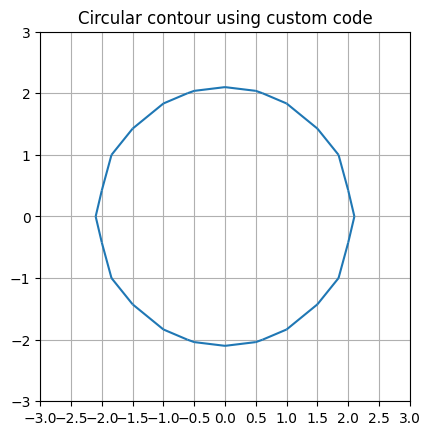

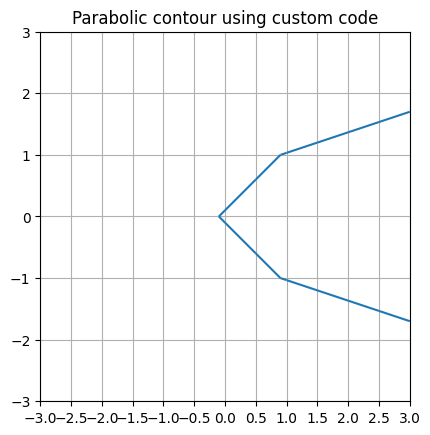

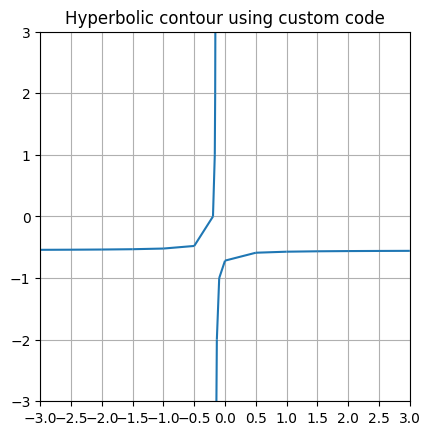

In [10]:
def test_plot_contour_custom():
    """ Test plot_contour_custom on some examples """
    
    plot_contour_custom(x_grid, y_grid, z_circular, "Circular contour using custom code")
    plot_contour_custom(x_grid, y_grid, z_parabolic, "Parabolic contour using custom code")    
    plot_contour_custom(x_grid, y_grid, z_hyperbolic, "Hyperbolic contour using custom code")
      
test_plot_contour_custom()